# System-size ladder for the chiral solution

The Nambu-basis models are known to lose the per-site topological
eigenvector; that comparison lives in the four-model study. This notebook
asks a narrower question about the **chiral** surrogate alone:

> as the chain grows from `N = 5` to `N = 100` sites, at a fixed training
> budget, does the quality of the chiral solution hold?

It reads a finished `chiral_n_sweep.py` run -- the CSV plus the per-seed
checkpoints -- and never trains. The theory it checks against is
`docs/markdown/derivations/under-determination-and-n-scaling.md` Sec. 5: the chiral
model learns the smallest singular pair of an `N x N` block `h(mu)`, whose
well-posedness is set by an `O(t)` singular gap that **does not close with
`N`**, so the solution should stay determined at every system size.

Every figure is written to `figures/analysis/` next to the run at 300 dpi.
The figures carry only descriptive titles and axis labels; all of the
interpretation is in these markdown cells.

**Prerequisite.** A finished run under
`results/logs/<timestamp>_chiral-n-sweep/` with `chiral_n_sweep.csv` and
`checkpoints/chiral/N<n>/seed_<s>.pt`. Produce one with

```
python experiments/chiral_n_sweep.py --n-values 5 10 25 50 75 100 --seeds 0 1 2
```

## Setup

`chiral_n_sweep.py` is a sibling module under `experiments/`; put that
directory on the path so its constants (`MU_GRID`, `T`, `DELTA`,
`TRANSITION`) and its checkpoint loader (`_rebuild_adapter`) are reused
rather than re-derived.

In [1]:
%matplotlib inline
import sys
import warnings
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Walk up from ``start`` until ``experiments/chiral_n_sweep.py`` is visible."""
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "chiral_n_sweep.py").exists():
            return candidate
    raise FileNotFoundError("could not locate the repository root")


REPO = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO / "experiments"))
warnings.filterwarnings("ignore", category=RuntimeWarning)
print(f"repo root: {REPO}")

repo root: /Users/dev/Projects/pinn-1d-kitaev-chain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from chiral_n_sweep import DELTA, MU_GRID, TRANSITION, T, _rebuild_adapter
from IPython.display import display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap

from kitaev.analytical import KitaevChainHamiltonian, chiral_block
from kitaev.visualisation.style import CORAL, INK, SLATE, TEAL, use_house_style

use_house_style()
# Publication overrides: plain (non-bold) titles, tighter type, crisp export.
plt.rcParams.update(
    {
        "axes.titleweight": "normal",
        "axes.titlesize": 11,
        "axes.titlepad": 8,
        "axes.labelsize": 10,
        "axes.labelweight": "normal",
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "legend.fontsize": 8.5,
        "lines.linewidth": 1.6,
        "lines.markersize": 5,
    }
)

# Roles, from the project house palette:
#   CORAL  the chiral model / predicted quantity
#   INK    an exact, well-posed reference (p_star)
#   TEAL   the gauge-invariant pair density
#   SLATE  the degenerate eigh reference, and secondary guides
DEVICE = "cpu"
KIND = "chiral"

# Perceptually uniform ramp for "one curve per N", trimmed to stay legible
# on white (no pale yellow, no near-black that clashes with INK).
_VIRIDIS = plt.get_cmap("viridis")
N_CMAP = LinearSegmentedColormap.from_list(
    "N_seq", _VIRIDIS(np.linspace(0.06, 0.80, 256))
)

### Run directory and output location

The most recent `*_chiral-n-sweep` session is used by default. Figures are
written next to the run in `figures/analysis/`, so the analysis travels
with the data it summarises.

In [3]:
_sessions = sorted((REPO / "results" / "logs").glob("*chiral-n-sweep"))
assert _sessions, "no *_chiral-n-sweep run found under results/logs/"
RUN_DIR = _sessions[-1]
CSV_PATH = RUN_DIR / "chiral_n_sweep.csv"
FIG_DIR = RUN_DIR / "figures" / "analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPO = np.abs(MU_GRID) < TRANSITION  # |mu| < 2t, the topological window
XI0 = 2.0 / np.log(3.0)  # decay length at mu = 0, in sites
EPS64 = np.finfo(np.float64).eps
EPS32 = np.finfo(np.float32).eps

print(f"run:     {RUN_DIR.name}")
print(f"csv:     {CSV_PATH.relative_to(REPO)}")
print(f"figures: {FIG_DIR.relative_to(REPO)}")
print(
    f"mu grid: {MU_GRID.size} points on [{MU_GRID.min():g}, {MU_GRID.max():g}], "
    f"{int(TOPO.sum())} in the topological window"
)


def savefig(fig: plt.Figure, name: str) -> None:
    """Write ``fig`` to ``FIG_DIR/name`` and report the path."""
    path = FIG_DIR / name
    fig.savefig(path)
    print(f"saved {path.relative_to(REPO)}")


def n_colours(n_values: list[int]) -> dict[int, tuple]:
    """One ramp colour per N, spaced by rank so every curve is distinct."""
    return {n: N_CMAP(i / max(len(n_values) - 1, 1)) for i, n in enumerate(n_values)}

run:     20260829_144145_chiral-n-sweep
csv:     results/logs/20260829_144145_chiral-n-sweep/chiral_n_sweep.csv
figures: results/logs/20260829_144145_chiral-n-sweep/figures/analysis
mu grid: 240 points on [-4, 4], 120 in the topological window


## The sweep at a glance

`chiral` is trained for 9000 AdamW epochs at each rung (the pilot
plateau), three seeds per rung.

**What the metric columns mean, in plain terms.**

| column | plain reading |
|---|---|
| `e_mae_topological` | how far the predicted lowest energy is from exact diagonalisation, averaged over the topological region (chemical potential within `2t` of zero). Small = right energy. |
| `subspace_infidelity_{mean,max}` | the two near-zero states span a 2-D space `M`; this is how much of the predicted state lies *outside* `M` (`0` = perfectly inside, `1` = fully outside), averaged / worst over the chemical potential. |
| `pair_density_mae_topo` | error in the *combined* per-site probability of the two near-zero states. Adding the pair cancels their arbitrary internal mixing, so this is a fair physical test. |
| `raw_density_mae_topo` | error of a *single* predicted state's per-site probability against one eigenvector `numpy` returns. Only meaningful if that eigenvector is itself well defined (it is not, for large `N` -- Sec. 2). |
| `gauge_gap` | `raw - pair`: the part of the single-vector error that is pure internal-mixing ambiguity. |

The `structural_nambu` rows in the CSV are dropped here; the point of this
notebook is the chiral trend in isolation.

In [4]:
runs = (
    pd.read_csv(CSV_PATH)
    .query("model == @KIND")
    .sort_values(["n_sites", "seed"])
    .reset_index(drop=True)
)
N_VALUES = sorted(runs.n_sites.unique())
SEEDS = sorted(runs.seed.unique())
NCOL = n_colours(N_VALUES)
display(runs.set_index(["n_sites", "seed"]))

model  adam_epochs  e_mae_topological  \
n_sites seed                                           
5       0     chiral         9000       9.216455e-06   
        1     chiral         9000       3.025060e-08   
        2     chiral         9000       2.251107e-06   
10      0     chiral         9000       1.747906e-06   
        1     chiral         9000       7.275113e-06   
        2     chiral         9000       6.690280e-06   
25      0     chiral         9000       1.374431e-05   
        1     chiral         9000       2.123364e-05   
        2     chiral         9000       3.040328e-05   
50      0     chiral         9000       6.731498e-06   
        1     chiral         9000       1.349939e-05   
        2     chiral         9000       1.640885e-06   
75      0     chiral         9000       2.668836e-05   
        1     chiral         9000       3.218193e-06   
        2     chiral         9000       5.886648e-06   
100     0     chiral         9000       2.902975e-05   
        1     chiral         9000       1.465706e-05   
        2     chiral         9000       2.714788e-05   

              subspace_infidelity_mean  subspace_infidelity_max  \
n_sites seed                                                      
5       0                 4.288337e-06             5.422056e-05   
        1                -9.235697e-09             7.802416e-08   
        2                 1.151822e-06             8.924867e-06   
10      0                 1.918781e-06             1.832850e-05   
        1                 4.210089e-06             1.993561e-04   
        2                 1.143484e-05             7.167516e-05   
25      0                 1.050414e-04             9.766499e-03   
        1                 5.437516e-05             1.736231e-03   
        2                 7.161478e-05             1.208886e-03   
50      0                 7.546899e-05             2.610495e-03   
        1                 7.623443e-05             1.932797e-03   
        2                 2.503919e-05             1.938490e-03   
75      0                 1.851379e-04             7.845060e-03   
        1                 1.054925e-04             3.300560e-03   
        2                 6.666865e-05             2.149983e-03   
100     0                 3.067812e-04             1.645127e-02   
        1                 3.084401e-04             9.193740e-03   
        2                 4.903660e-04             1.905771e-02   

              pair_density_mae_topo  raw_density_mae_topo  gauge_gap  \
n_sites seed                                                           
5       0                  0.000463              0.000940   0.000477   
        1                  0.000029              0.000053   0.000024   
        2                  0.000302              0.000497   0.000194   
10      0                  0.000141              0.000921   0.000780   
        1                  0.000157              0.000982   0.000825   
        2                  0.000265              0.001244   0.000978   
25      0                  0.000216              0.000292   0.000076   
        1                  0.000258              0.000330   0.000073   
        2                  0.000310              0.000418   0.000108   
50      0                  0.000064              0.000101   0.000037   
        1                  0.000096              0.000148   0.000052   
        2                  0.000030              0.000048   0.000018   
75      0                  0.000077              0.011532   0.011455   
        1                  0.000038              0.011496   0.011458   
        2                  0.000033              0.011492   0.011459   
100     0                  0.000057              0.008832   0.008775   
        1                  0.000060              0.008797   0.008737   
        2                  0.000062              0.008800   0.008739   

              wall_seconds  
n_sites seed                
5       0            375.7  
        1            368.

In [5]:
# Per-N median with the inter-seed spread and the worst seed, plus fixed-bar
# pass-rates. Bars: energy MAE < 1e-4, pair-density MAE < 1e-3 -- the
# "recovered" thresholds used elsewhere in the project.
METRICS = [
    "e_mae_topological",
    "subspace_infidelity_mean",
    "subspace_infidelity_max",
    "pair_density_mae_topo",
    "raw_density_mae_topo",
]
BARS = {"e_mae_topological": 1e-4, "pair_density_mae_topo": 1e-3}


def _summarise(group: pd.DataFrame) -> pd.Series:
    out: dict[str, float] = {"seeds": len(group)}
    for m in METRICS:
        out[f"{m}__med"] = group[m].median()
        out[f"{m}__iqr"] = group[m].quantile(0.75) - group[m].quantile(0.25)
        out[f"{m}__worst"] = group[m].max()
    for m, bar in BARS.items():
        out[f"{m}__pass@{bar:g}"] = float((group[m] < bar).mean())
    return pd.Series(out)


summary = runs.groupby("n_sites").apply(_summarise, include_groups=False)
pd.set_option(
    "display.float_format", lambda v: f"{v:.3e}" if abs(v) < 1 else f"{v:.3g}"
)
display(summary)

,seeds,e_mae_topological__med,e_mae_topological__iqr,e_mae_topological__worst,subspace_infidelity_mean__med,subspace_infidelity_mean__iqr,subspace_infidelity_mean__worst,subspace_infidelity_max__med,subspace_infidelity_max__iqr,subspace_infidelity_max__worst,pair_density_mae_topo__med,pair_density_mae_topo__iqr,pair_density_mae_topo__worst,raw_density_mae_topo__med,raw_density_mae_topo__iqr,raw_density_mae_topo__worst,e_mae_topological__pass@0.0001,pair_density_mae_topo__pass@0.001
n_sites,,,,,,,,,,,,,,,,,,
5,3,2.251e-06,4.593e-06,9.216e-06,1.152e-06,2.149e-06,4.288e-06,8.925e-06,2.707e-05,5.422e-05,3.024e-04,2.174e-04,4.634e-04,4.967e-04,4.436e-04,9.403e-04,1,1
10,3,6.690e-06,2.764e-06,7.275e-06,4.210e-06,4.758e-06,1.143e-05,7.168e-05,9.051e-05,1.994e-04,1.566e-04,6.200e-05,2.655e-04,9.820e-04,1.613e-04,1.244e-03,1,1
25,3,2.123e-05,8.329e-06,3.040e-05,7.161e-05,2.533e-05,1.050e-04,1.736e-03,4.279e-03,9.766e-03,2.576e-04,4.719e-05,3.105e-04,3.301e-04,6.331e-05,4.182e-04,1,1
50,3,6.731e-06,5.929e-06,1.350e-05,7.547e-05,2.560e-05,7.623e-05,1.938e-03,3.388e-04,2.610e-03,6.436e-05,3.313e-05,9.641e-05,1.013e-04,5.004e-05,1.479e-04,1,1
75,3,5.887e-06,1.174e-05,2.669e-05,1.055e-04,5.923e-05,1.851e-04,3.301e-03,2.848e-03,7.845e-03,3.805e-05,2.192e-05,7.732e-05,1.150e-02,2.011e-05,1.153e-02,1,1
100,3,2.715e-05,7.186e-06,2.903e-05,3.084e-04,9.179e-05,4.904e-04,1.645e-02,4.932e-03,1.906e-02,6.026e-05,2.383e-06,6.176e-05,8.800e-03,1.720e-05,8.832e-03,1,1


## 1. Gauge-invariant quality versus `N`

These quantities do not depend on how the two near-zero states are mixed
together, so they are a fair per-`mu` test of the physics in the
topological phase.

**How to read the figure.** Solid line = seed median; shaded band =
inter-quartile range over the three seeds; faint dots = individual seeds;
grey dashed line = the project's "recovered" threshold (`1e-4` for energy,
`1e-3` for density).

**What it shows.**

* **Energy MAE** is essentially flat, `~1e-5` to `~3e-5` across the whole
  ladder -- a slight rise with `N` as the `2N`-spectrum problem grows -- and
  stays a factor of a few inside the `1e-4` threshold at every rung.
* **Pair-density MAE** actually *improves* with `N`, from `~3e-4` at
  `N = 5` to `~6e-5` at `N = 100`: a longer chain localises the edge mode
  more tightly, so the correct density is easier to represent.
* **Subspace infidelity** is the one quantity that degrades: the mean rises
  from `~1e-6` at `N = 5` to `~3e-4` at `N = 100`, the worst-`mu` value to
  `~1e-2`. At a fixed 9000-epoch budget, projecting cleanly onto a larger
  space `M` is simply less converged. It is a budget effect, not a
  well-posedness one (Sec. 3), and the absolute level is still small.

saved results/logs/20260829_144145_chiral-n-sweep/figures/analysis/chiral_gauge_invariant_vs_N.png


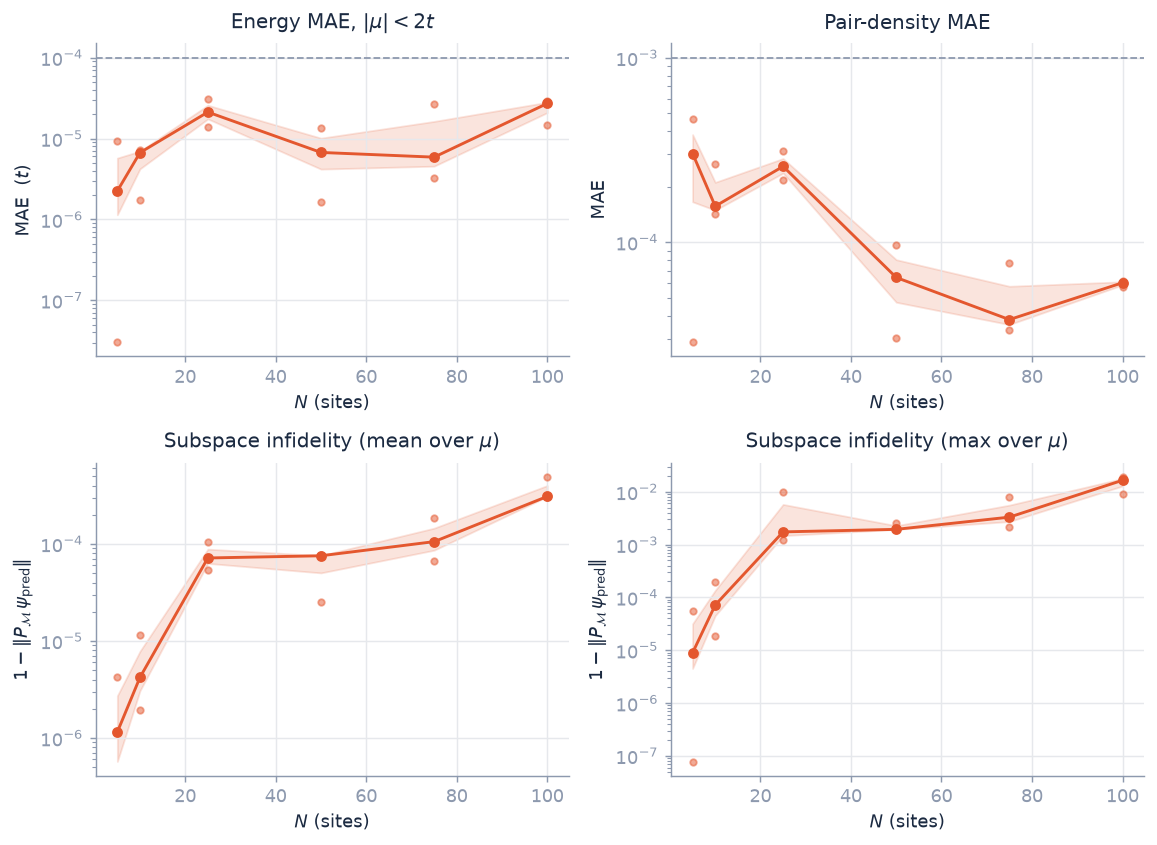

In [6]:
def band(ax: plt.Axes, df: pd.DataFrame, col: str, *, colour: str = CORAL) -> None:
    """Seed-median line, inter-quartile band, and per-seed points, vs N."""
    g = df.groupby("n_sites")[col]
    n = np.array(sorted(df.n_sites.unique()))
    ax.plot(n, g.median().reindex(n), "-o", color=colour, zorder=3)
    ax.fill_between(
        n,
        g.quantile(0.25).reindex(n),
        g.quantile(0.75).reindex(n),
        color=colour,
        alpha=0.16,
        zorder=1,
    )
    ax.scatter(df.n_sites, df[col], s=13, color=colour, alpha=0.5, zorder=2)
    ax.set_xlabel(r"$N$ (sites)")
    ax.set_yscale("log")


fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.6))
panels = [
    ("e_mae_topological", r"Energy MAE, $|\mu| < 2t$", r"MAE  ($t$)"),
    ("pair_density_mae_topo", r"Pair-density MAE", "MAE"),
    (
        "subspace_infidelity_mean",
        r"Subspace infidelity (mean over $\mu$)",
        r"$1 - \| P_{\mathcal{M}}\,\psi_{\mathrm{pred}} \|$",
    ),
    (
        "subspace_infidelity_max",
        r"Subspace infidelity (max over $\mu$)",
        r"$1 - \| P_{\mathcal{M}}\,\psi_{\mathrm{pred}} \|$",
    ),
]
for ax, (col, title, ylab) in zip(axes.flat, panels, strict=False):
    band(ax, runs, col)
    ax.set_title(title)
    ax.set_ylabel(ylab)
    if col in BARS:
        ax.axhline(BARS[col], color=SLATE, ls="--", lw=1)
fig.tight_layout()
savefig(fig, "chiral_gauge_invariant_vs_N.png")
plt.show()

## 2. The recorded `raw_density` column breaks past `N ~ 50`

**Plain terms.** `raw_density_mae_topo` grades a *single* predicted state
against one specific eigenvector that `numpy.linalg.eigh(H(mu))` hands
back. That only works while `numpy`'s eigenvector is itself well defined.
The two near-zero states become numerically identical in energy around
`N ~ 60` (Sec. 3), and past that point `eigh` returns an essentially
random member of the pair, so `raw_density` is scoring against a
coin-flip.

**How to read the figure.** Both curves are seed medians for the chiral
model. Circles: the gauge-invariant `pair_density` (well defined at every
`N`). Squares: the recorded `raw_density`. They agree up to `N = 50`; at
`N = 75, 100` the `raw` value jumps to `~1e-2` -- and does so *identically
across seeds* (spread `< 1e-4`), the signature of a broken reference
rather than a broken model. Section 4 rebuilds the metric with a reference
that stays well posed.

saved results/logs/20260829_144145_chiral-n-sweep/figures/analysis/chiral_recorded_density_vs_N.png


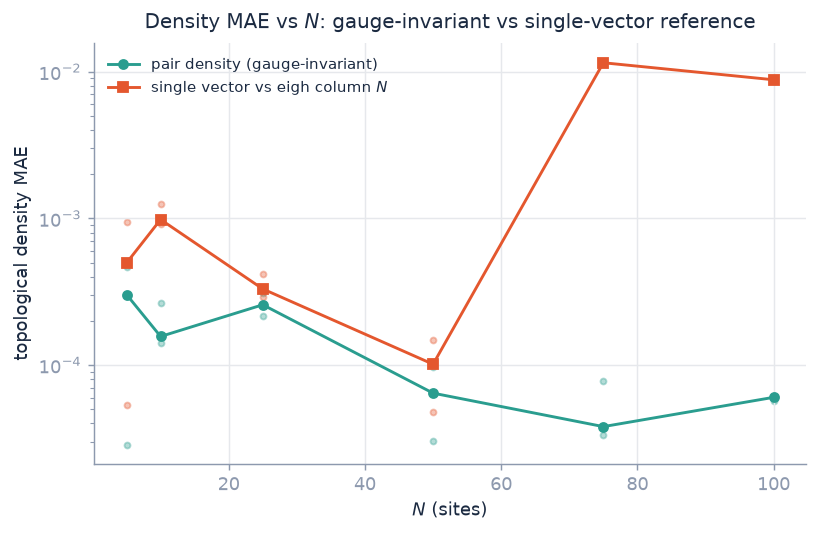

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
n = np.array(N_VALUES)
for col, marker, colour, lab in (
    ("pair_density_mae_topo", "o", TEAL, "pair density (gauge-invariant)"),
    ("raw_density_mae_topo", "s", CORAL, "single vector vs eigh column $N$"),
):
    g = runs.groupby("n_sites")[col]
    ax.plot(n, g.median().reindex(n), "-", marker=marker, color=colour, label=lab)
    ax.scatter(runs.n_sites, runs[col], s=11, color=colour, alpha=0.35)
ax.set_yscale("log")
ax.set_xlabel(r"$N$ (sites)")
ax.set_ylabel(r"topological density MAE")
ax.set_title(r"Density MAE vs $N$: gauge-invariant vs single-vector reference")
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "chiral_recorded_density_vs_N.png")
plt.show()

## 3. The chiral block's spectrum versus `N`

**Plain terms.** `h(mu)` is the `N x N` matrix the chiral network actually
solves.

* `sigma_1` is its smallest singular value -- physically the tiny energy
  splitting between the two Majorana end states. It shrinks exponentially
  with chain length, `sigma_1 ~ e^{-N / xi}` with `xi(0) = 2 / ln 3 ~ 1.82`
  sites.
* `sigma_2` is the next singular value up -- the gap to the rest of the
  spectrum, a bulk quantity `~1.0 t` at `mu = 0` and `~0.82 t` at
  `mu = 1t`, and **flat in `N`**.

The network's problem is well posed because it only needs the **gap**
`sigma_2 - sigma_1` (which never closes), not `sigma_1` itself (which
vanishes). The dashed lines mark the smallest number each float type can
represent: once `sigma_1` (left) or the selection signal `sigma_1^2`
(right) drops below them, any procedure that leans on `sigma_1` -- including
`eigh`'s choice of near-zero eigenvectors -- is running on rounding error.
That crossing (`sigma_1` below `float64` near `N ~ 65`) is exactly where
Section 2's metric broke.

saved results/logs/20260829_144145_chiral-n-sweep/figures/analysis/chiral_block_spectrum_vs_N.png


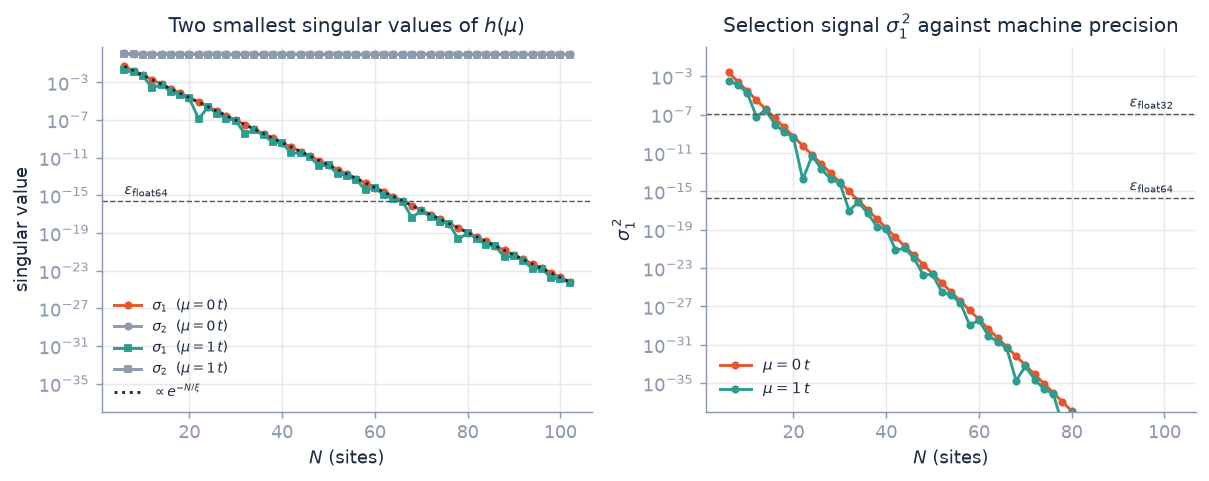

In [8]:
n_dense = np.arange(6, 104, 2)


def two_smallest_sv(mu: float, n_sites: int) -> tuple[float, float]:
    """``(sigma_1, sigma_2)`` of ``h(mu)`` -- smallest and next singular value."""
    s = np.linalg.svd(
        chiral_block(mu, n_sites=n_sites, hopping=T, pairing=DELTA), compute_uv=False
    )
    return float(s[-1]), float(s[-2])


sig = {
    mu: np.array([two_smallest_sv(mu, int(n)) for n in n_dense]) for mu in (0.0, 1.0)
}

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8))

ax = axes[0]
for mu, mk in ((0.0, "o"), (1.0, "s")):
    c = CORAL if mu == 0 else TEAL
    ax.semilogy(
        n_dense,
        np.clip(sig[mu][:, 0], 1e-300, None),
        "-",
        marker=mk,
        ms=3.5,
        color=c,
        label=rf"$\sigma_1$  ($\mu = {mu:g}\,t$)",
    )
    ax.semilogy(
        n_dense,
        sig[mu][:, 1],
        "-",
        marker=mk,
        ms=3.5,
        color=SLATE,
        label=rf"$\sigma_2$  ($\mu = {mu:g}\,t$)",
    )
ref = np.exp(-n_dense / XI0) * sig[0.0][0, 0] / np.exp(-n_dense[0] / XI0)
ax.semilogy(n_dense, ref, ":", color=INK, label=r"$\propto e^{-N/\xi}$")
ax.axhline(EPS64, color="0.35", lw=0.8, ls="--")
ax.text(
    n_dense[0], EPS64 * 2, r"$\epsilon_{\mathrm{float64}}$", fontsize=8, va="bottom"
)
ax.set_ylim(1e-38, 5)
ax.set_xlabel(r"$N$ (sites)")
ax.set_ylabel("singular value")
ax.set_title(r"Two smallest singular values of $h(\mu)$")
ax.legend(frameon=False, fontsize=7.5, loc="lower left", ncol=1)

ax = axes[1]
for mu, c in ((0.0, CORAL), (1.0, TEAL)):
    ax.semilogy(
        n_dense,
        np.clip(sig[mu][:, 0] ** 2, 1e-300, None),
        "-o",
        ms=3.5,
        color=c,
        label=rf"$\mu = {mu:g}\,t$",
    )
for eps, name in ((EPS64, "float64"), (EPS32, "float32")):
    ax.axhline(eps, color="0.35", lw=0.8, ls="--")
    ax.text(
        n_dense[-1],
        eps * 2,
        rf"$\epsilon_{{\mathrm{{{name}}}}}$",
        fontsize=8,
        va="bottom",
        ha="right",
    )
ax.set_ylim(1e-38, 1)
ax.set_xlabel(r"$N$ (sites)")
ax.set_ylabel(r"$\sigma_1^{\,2}$")
ax.set_title(r"Selection signal $\sigma_1^{\,2}$ against machine precision")
ax.legend(frameon=False, loc="lower left")

fig.tight_layout()
savefig(fig, "chiral_block_spectrum_vs_N.png")
plt.show()

## 4. Per-site density error against a well-posed reference

Sections 1-2 graded the *pair* density -- gauge-invariant, always well
defined. This section grades the harder quantity, a **single** predicted
state's probability at each site, and shows how to score it without the
broken `eigh` reference.

### What the figure plots

For every checkpoint we take the predicted per-site probability
`|psi_pred(n)|^2`, compare it site by site with a "correct answer",
average the absolute differences over sites and over `mu` in the
topological window, and plot that number -- the **per-site density MAE**,
log `y` -- against chain length `N`. The shaded band is the inter-quartile
range over the three seeds; faint dots are the individual seeds.

The whole question is *which* correct answer to compare against. The
figure draws three choices, because that choice is the entire story:

| curve | reference it compares against | well defined? |
|---|---|---|
| coral, solid, circles (`vs p_star`) | `p_star` -- the specific "weight-on-both-ends" state, rebuilt from the chiral block's smallest singular pair | yes, at every `N` |
| teal, solid, triangles (`pair density`) | the *sum* of both near-zero states' densities; adding the pair cancels their arbitrary internal mixing | yes, at every `N` |
| grey, dotted, squares (`vs eigh column N`) | one near-zero eigenvector `numpy.linalg.eigh` happens to return -- the `raw_density_mae_topo` column straight from the CSV | only for `N <= 50` |

### The well-posed reference `p_star`

`p_star` is the per-site probability (particle + hole) of the `+lambda_1`
BdG eigenvector reconstructed from the smallest singular pair `(u_1, v_1)`
of `h(mu)`,

$$
p_\star(n) \;=\; \tfrac{1}{2}\big(u_1(n)^2 + v_1(n)^2\big),
\qquad
\psi_+ = \big((u_1 + v_1)/2,\ (u_1 - v_1)/2\big).
$$

It is identical for `psi_+` and its particle-hole partner, so it carries
no mixing ambiguity, and `(u_1, v_1)` stay well defined at every `N`
because the gap `sigma_2` above them is `O(t)` (Sec. 3) even where
`sigma_1` itself has underflowed. The table below re-scores every chiral
checkpoint against `p_star` (`raw_vs_canon`) and, for comparison, against
the old `eigh` reference (`raw_vs_eigh`, which reproduces the CSV column).

In [9]:
def canonical_density(mu: float, n_sites: int) -> np.ndarray:
    """``p_star(n) = (u_1^2 + v_1^2) / 2`` from the smallest singular pair of h(mu)."""
    h = chiral_block(mu, n_sites=n_sites, hopping=T, pairing=DELTA)
    u, _, vt = np.linalg.svd(h)
    return 0.5 * (u[:, -1] ** 2 + vt[-1, :] ** 2)


def eigh_density(mu: float, n_sites: int) -> np.ndarray:
    """The per-site reference the sweep used: ``vecs[:, N] ** 2``, folded."""
    ham = KitaevChainHamiltonian(n_sites=n_sites, hopping=T, pairing=DELTA)
    _, vecs = np.linalg.eigh(ham.build(mu))
    ref = vecs[:, n_sites] ** 2
    return ref[:n_sites] + ref[n_sites:]


def model_densities(n_sites: int, seed: int) -> np.ndarray:
    """Per-site density (mu, site) of one chiral checkpoint over the mu grid."""
    ckpt = RUN_DIR / "checkpoints" / KIND / f"N{n_sites}" / f"seed_{seed}.pt"
    adapter = _rebuild_adapter(KIND, n_sites, ckpt).to(DEVICE)
    with torch.no_grad():
        _, psi_t = adapter(
            torch.tensor(MU_GRID[:, None], dtype=torch.float32, device=DEVICE)
        )
    psi = psi_t.cpu().numpy()
    psi = psi / np.linalg.norm(psi, axis=1, keepdims=True)
    return psi[:, :n_sites] ** 2 + psi[:, n_sites:] ** 2


# References depend only on (mu, N); build them once for the topological grid.
_ref = {
    (n, tag): np.array([fn(float(mu), n) for mu in MU_GRID[TOPO]])
    for n in N_VALUES
    for tag, fn in (("canon", canonical_density), ("eigh", eigh_density))
}
# Every chiral checkpoint's per-site density on the topological grid, cached
# for reuse in Sections 4-6.
DENS = {(n, s): model_densities(n, s)[TOPO] for n in N_VALUES for s in SEEDS}

rows = []
for n in N_VALUES:
    for seed in SEEDS:
        d = DENS[(n, seed)]
        rows.append(
            {
                "n_sites": n,
                "seed": seed,
                "raw_vs_canon": float(np.abs(d - _ref[(n, "canon")]).mean()),
                "raw_vs_eigh": float(np.abs(d - _ref[(n, "eigh")]).mean()),
            }
        )
recomputed = pd.DataFrame(rows)
display(
    recomputed.groupby("n_sites")[["raw_vs_canon", "raw_vs_eigh"]].agg(
        ["median", "max"]
    )
)

raw_vs_canon           raw_vs_eigh          
              median       max      median       max
n_sites                                             
5          3.024e-04 4.634e-04   3.024e-04 4.634e-04
10         1.566e-04 2.655e-04   1.566e-04 2.655e-04
25         2.576e-04 3.105e-04   2.576e-04 3.105e-04
50         6.436e-05 9.641e-05   6.798e-05 9.935e-05
75         3.805e-05 7.732e-05   1.147e-02 1.151e-02
100        6.026e-05 6.176e-05   8.775e-03 8.777e-03

saved results/logs/20260829_144145_chiral-n-sweep/figures/analysis/chiral_density_error_vs_N.png


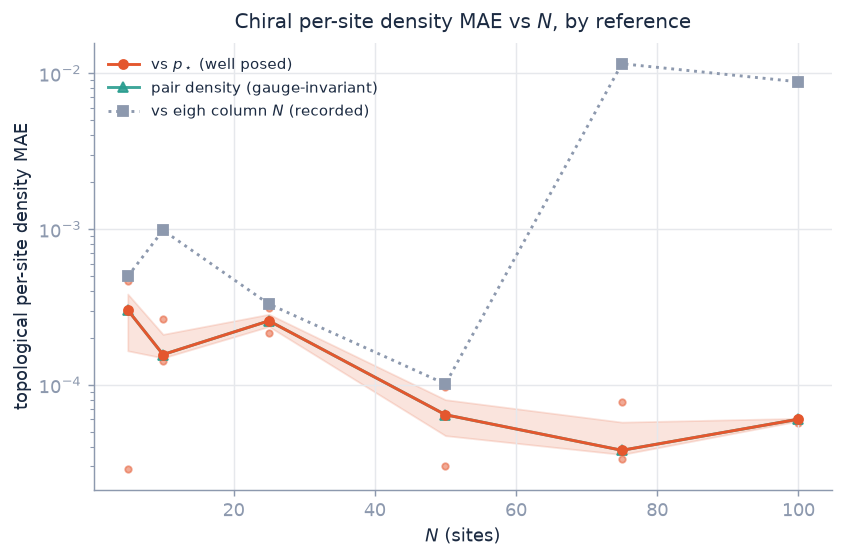

In [10]:
fig, ax = plt.subplots(figsize=(6.6, 4.4))
n = np.array(N_VALUES)
g = recomputed.groupby("n_sites")["raw_vs_canon"]
ax.plot(
    n,
    g.median().reindex(n),
    "-o",
    color=CORAL,
    zorder=3,
    label=r"vs $p_\star$ (well posed)",
)
ax.fill_between(
    n, g.quantile(0.25).reindex(n), g.quantile(0.75).reindex(n), color=CORAL, alpha=0.16
)
ax.scatter(recomputed.n_sites, recomputed.raw_vs_canon, s=13, color=CORAL, alpha=0.5)
ax.plot(
    n,
    runs.groupby("n_sites")["pair_density_mae_topo"].median().reindex(n),
    "-^",
    color=TEAL,
    alpha=0.9,
    label="pair density (gauge-invariant)",
)
ax.plot(
    n,
    runs.groupby("n_sites")["raw_density_mae_topo"].median().reindex(n),
    ":s",
    color=SLATE,
    label="vs eigh column $N$ (recorded)",
)
ax.set_yscale("log")
ax.set_xlabel(r"$N$ (sites)")
ax.set_ylabel("topological per-site density MAE")
ax.set_title(r"Chiral per-site density MAE vs $N$, by reference")
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "chiral_density_error_vs_N.png")
plt.show()

### Reading the figure

* **Coral and teal sit on top of each other and slide downward** -- from
  `~3e-4` at `N = 5` to `~6e-5` at `N = 100`. Two independent well-posed
  references agree: the chiral per-site density gets *more* accurate on
  longer chains, because the edge mode localises more tightly and is
  easier to represent.
* **The grey dotted line follows them to `N = 50`, then jumps to `~1e-2`**
  at `N = 75, 100`. That jump is **not the model getting worse** -- it is
  the ruler breaking. By `N ~ 60` the two near-zero states are numerically
  identical in energy (Sec. 3), so `eigh` returns an essentially random
  mixture of them, and comparing any fixed state to a random target scores
  `~1e-2`. This is the `raw_density_mae_topo` / `gauge_gap` artefact from
  Section 2, now seen against the corrected reference.
* The small-`N` end of the coral curve is its own worst point, dominated
  by the `mu = 0` fold kink, which covers a larger fraction of the fixed
  topological window when that window is short (Sec. 5).

**Takeaway.** Against a reference that stays well defined, the chiral
per-site density error *falls* with `N`; the alarming rise in the recorded
CSV column at large `N` is an artefact of the `eigh` reference, not of the
network.

## 5. Where in `mu` does the residual live?

**Plain terms.** The single topological-window number in Section 4 is an
average; this splits it by `mu`. For each `N`, the seed-median per-site
density MAE against `p_star` is drawn as a function of `mu`.

**What it shows.**

* The error is worst **approaching the phase boundary `|mu| -> 2t`**: the
  energy gap closes there and the end state spreads across the whole chain,
  the hardest place for a smooth network to fit.
* There is a smaller, narrow bump **exactly at `mu = 0`** from a sign flip
  in the exact solution (`u(-mu) = -D u(mu)`) that a smooth network cannot
  reproduce. The strip `|mu| < 0.01t` (grey band) is left out of training
  for this reason. The bump only matters at small `N` (clearest at
  `N = 10`) and has sunk into the background by `N >= 50`.
* Everywhere else the error is a **low, flat floor**. All three parts --
  edge, kink, floor -- come down by roughly an order of magnitude from
  `N = 5` to `N = 100`.

The colour bar runs from `N = 5` (dark) to `N = 100` (light). The
companion table splits the window-averaged MAE into the `mu = 0` core, the
bulk, and the approach to the transition.

saved results/logs/20260829_144145_chiral-n-sweep/figures/analysis/chiral_residual_vs_mu.png


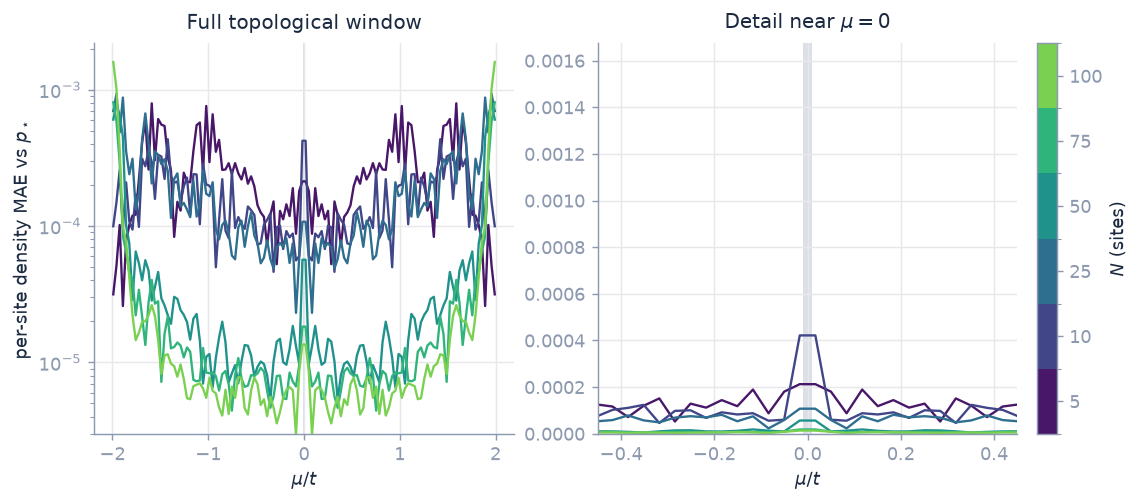

In [11]:
mu_topo = MU_GRID[TOPO]
err_by_n = {
    n: np.median(
        [np.abs(DENS[(n, s)] - _ref[(n, "canon")]).mean(axis=1) for s in SEEDS],
        axis=0,
    )
    for n in N_VALUES
}

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))
for n in N_VALUES:
    axes[0].plot(mu_topo, err_by_n[n], color=NCOL[n], lw=1.3)
    axes[1].plot(mu_topo, err_by_n[n], color=NCOL[n], lw=1.3)
axes[0].set_yscale("log")
axes[0].set_ylim(3e-6, None)
axes[0].set_title("Full topological window")
axes[0].set_ylabel(r"per-site density MAE vs $p_\star$")
axes[1].set_xlim(-0.45, 0.45)
axes[1].set_ylim(0, None)
axes[1].set_title(r"Detail near $\mu = 0$")
for ax in axes:
    ax.axvspan(-0.01, 0.01, color=SLATE, alpha=0.30, lw=0)
    ax.set_xlabel(r"$\mu / t$")

# Discrete colour bar, one band per swept N (curves are coloured by rank).
disc = ListedColormap([NCOL[n] for n in N_VALUES])
bnorm = BoundaryNorm(np.arange(len(N_VALUES) + 1) - 0.5, len(N_VALUES))
cbar = fig.colorbar(
    ScalarMappable(norm=bnorm, cmap=disc),
    ax=axes,
    ticks=range(len(N_VALUES)),
    pad=0.02,
    fraction=0.045,
)
cbar.ax.set_yticklabels([str(n) for n in N_VALUES])
cbar.set_label(r"$N$ (sites)")
savefig(fig, "chiral_residual_vs_mu.png")
plt.show()

In [12]:
# Seed-median density MAE in three mu zones, per N: the mu = 0 fold core,
# the bulk of the window, and the approach to the transition.
zones = {
    "fold  |mu| < 0.1t": np.abs(mu_topo) < 0.1,
    "bulk  0.1 <= |mu| <= 1.8t": (np.abs(mu_topo) >= 0.1) & (np.abs(mu_topo) <= 1.8),
    "edge  |mu| > 1.8t": np.abs(mu_topo) > 1.8,
}
split = []
for n in N_VALUES:
    d = np.median([np.abs(DENS[(n, s)] - _ref[(n, "canon")]) for s in SEEDS], axis=0)
    split.append({"n_sites": n, **{k: float(d[m].mean()) for k, m in zones.items()}})
split_df = pd.DataFrame(split).set_index("n_sites")
display(split_df)

,fold |mu| < 0.1t,bulk 0.1 <= |mu| <= 1.8t,edge |mu| > 1.8t
n_sites,,,
5,1.222e-04,2.337e-04,6.254e-05
10,1.697e-04,1.547e-04,1.371e-04
25,7.723e-05,1.484e-04,6.081e-04
50,2.335e-05,1.938e-05,3.647e-04
75,1.056e-05,1.203e-05,3.031e-04
100,7.313e-06,8.100e-06,5.015e-04


## 6. Seed reproducibility versus `N`

**Plain terms.** The chiral problem has a single right answer (up to an
overall sign), so different random seeds should converge to the *same*
density profile.

**What it shows.** Left two panels: the three seeds (coral) at `N = 25`
and `N = 100`, taken at `mu ~ t`, lie on top of each other and on the
reference `p_star` (grey). Right panel: the spread between seeds -- the
standard deviation of the per-site density across the three seeds,
averaged over sites and over the topological window -- is small everywhere
and *shrinks* with `N`, from `~3e-4` at `N = 25` to `~4e-5` at `N = 100`.
This rules out the network merely getting lucky on any one run.

saved results/logs/20260829_144145_chiral-n-sweep/figures/analysis/chiral_seed_reproducibility_vs_N.png


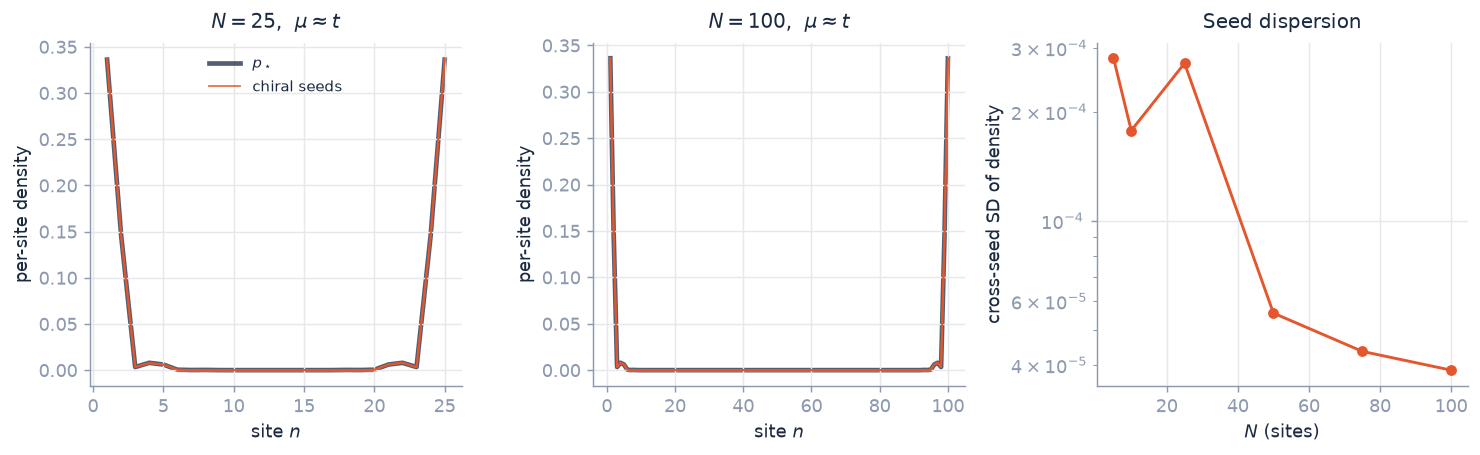

,seed_std
n_sites,
5,2.812e-04
10,1.775e-04
25,2.722e-04
50,5.561e-05
75,4.360e-05
100,3.870e-05


In [13]:
mu1_local = int(np.abs(mu_topo - 1.0).argmin())

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
for ax, n in zip(axes[:2], (25, 100), strict=False):
    sites = np.arange(1, n + 1)
    ax.plot(
        sites,
        canonical_density(float(mu_topo[mu1_local]), n),
        color=INK,
        lw=2.6,
        alpha=0.75,
        label=r"$p_\star$",
        zorder=1,
    )
    for j, s in enumerate(SEEDS):
        ax.plot(
            sites,
            DENS[(n, s)][mu1_local],
            color=CORAL,
            lw=1.0,
            alpha=0.85,
            label="chiral seeds" if j == 0 else None,
            zorder=2,
        )
    ax.set_title(rf"$N = {n}$,  $\mu \approx t$")
    ax.set_xlabel(r"site $n$")
    ax.set_ylabel("per-site density")
axes[0].legend(frameon=False)

disp = []
for n in N_VALUES:
    stack = np.array([DENS[(n, s)] for s in SEEDS])
    disp.append({"n_sites": n, "seed_std": float(stack.std(axis=0).mean())})
disp_df = pd.DataFrame(disp)
axes[2].plot(disp_df.n_sites, disp_df.seed_std, "-o", color=CORAL)
axes[2].set_yscale("log")
axes[2].set_xlabel(r"$N$ (sites)")
axes[2].set_ylabel("cross-seed SD of density")
axes[2].set_title("Seed dispersion")
fig.tight_layout()
savefig(fig, "chiral_seed_reproducibility_vs_N.png")
plt.show()
display(disp_df.set_index("n_sites"))

## 7. Training cost versus `N`

**Plain terms.** Wall-clock for one training run. The chiral network only
ever handles the `N x N` block `h(mu)` (not the full `2N x 2N`
Hamiltonian), and the epoch count is fixed at 9000, so the runtime barely
moves from `N = 5` to `N = 100` -- it is dominated by the fixed number of
optimiser steps, not by the linear-algebra size.

saved results/logs/20260829_144145_chiral-n-sweep/figures/analysis/chiral_wall_seconds_vs_N.png


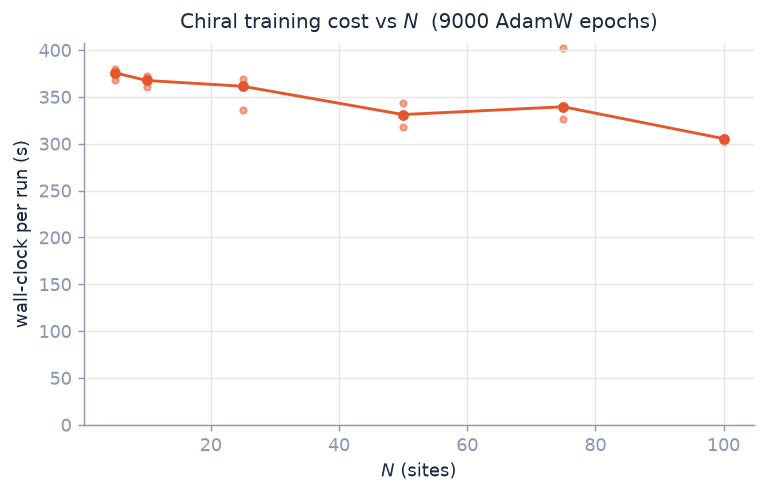

In [14]:
fig, ax = plt.subplots(figsize=(6.0, 3.9))
n = np.array(N_VALUES)
g = runs.groupby("n_sites")["wall_seconds"]
ax.plot(n, g.median().reindex(n), "-o", color=CORAL)
ax.scatter(runs.n_sites, runs.wall_seconds, s=13, color=CORAL, alpha=0.5)
ax.set_ylim(0, None)
ax.set_xlabel(r"$N$ (sites)")
ax.set_ylabel("wall-clock per run (s)")
ax.set_title(r"Chiral training cost vs $N$  (9000 AdamW epochs)")
fig.tight_layout()
savefig(fig, "chiral_wall_seconds_vs_N.png")
plt.show()

## 8. Verdict

**Does the chiral solution hold as `N` grows from 5 to 100?** Yes, with one
budget-limited caveat.

* **Energy** -- flat at `~1e-5`-`3e-5`, inside the `1e-4` threshold at
  every `N`.
* **Gauge-invariant density** (`pair_density`, and the recomputed per-site
  density against the well-posed `p_star`) -- *improves* with `N`, from
  `~3e-4` / `~5e-4` at `N = 5` to `~6e-5` at `N = 100`. A longer chain
  localises the edge mode more tightly and the solution tracks it better.
* **Seed reproducibility** -- the three seeds collapse onto one profile at
  every `N`, and the cross-seed spread *tightens* with `N` (`~3e-4` at
  `N = 25` to `~4e-5` at `N = 100`).
* **Residual structure** -- what error remains is largest approaching the
  transition `|mu| -> 2t`, where the gap closes and the mode delocalises;
  there is a smaller `mu = 0` fold kink that only matters at small `N`; the
  mid-window background is a flat, low floor. All three fall with `N`.
* **Cost** -- flat in `N` at a fixed epoch budget.
* **Caveat** -- subspace infidelity degrades mildly with `N` (mean
  `~1e-6 -> ~3e-4`, worst `mu` up to `~1e-2`) because a fixed 9000-epoch
  budget under-converges the projection onto a larger `M`. This is a
  budget effect, not a well-posedness one: the singular gap `sigma_2` that
  determines the chiral solution is `O(t)` and flat in `N` (Sec. 3). If a
  large-`N` rung must hold the infidelity threshold, raise its epoch count.

**Action item for the sweep.** `raw_density_mae_topo` and `gauge_gap` in
`chiral_n_sweep.csv` are trustworthy only for `N <= 50`. Past that the
`eigh` reference `vecs[:, N]` is an arbitrary member of a numerically
degenerate 2-D eigenspace (`sigma_1(0) ~ 3^{-N/2}` is below `float64`
round-off by `N ~ 33` and below `eigh`'s resolution against `||H||` by
`N ~ 66`). Reference the canonical `psi_+` from
`numpy.linalg.svd(chiral_block(mu, N))` in `evaluate()`
(`experiments/chiral_n_sweep.py`), or report only the gauge-invariant
`pair_density_mae_topo`, which is correct at every `N`.

In [15]:
print("figures written to", FIG_DIR.relative_to(REPO))
for p in sorted(FIG_DIR.glob("*.png")):
    print(" ", p.name)

figures written to results/logs/20260829_144145_chiral-n-sweep/figures/analysis
  chiral_block_spectrum_vs_N.png
  chiral_density_error_vs_N.png
  chiral_gauge_invariant_vs_N.png
  chiral_recorded_density_vs_N.png
  chiral_residual_vs_mu.png
  chiral_seed_reproducibility_vs_N.png
  chiral_wall_seconds_vs_N.png
